<a href="https://colab.research.google.com/github/sofiasanvi/PRO1/blob/main/Errors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Database_W5_OTU_occurences.tsv to Database_W5_OTU_occurences (7).tsv
{'TARA_N000000077': 938, 'TARA_A100001640': 3857, 'TARA_N000000835': 1776, 'TARA_N000000827': 6465, 'TARA_N000000839': 2762, 'TARA_N000000845': 1126, 'TARA_N000000837': 4085, 'TARA_N000000829': 7602, 'TARA_N000000833': 8045, 'TARA_N000000841': 2185, 'TARA_A100000402': 938, 'TARA_A100001646': 1660, 'TARA_A100000394': 2056, 'TARA_A100000393': 5924, 'TARA_A100000400': 2114, 'TARA_E500000200': 1455, 'TARA_A100000398': 1898, 'TARA_A100000396': 7791, 'TARA_E500000196': 3273, 'TARA_N000001664': 1520, 'TARA_N000001654': 3565, 'TARA_N000001646': 5254, 'TARA_N000001650': 5843, 'TARA_N000001658': 3505, 'TARA_N000001656': 3007, 'TARA_N000001648': 3713, 'TARA_N000001652': 4268, 'TARA_N000001660': 1510, 'TARA_A100000546': 934, 'TARA_A100000553': 3573, 'TARA_A100000551': 6900, 'TARA_A100001333': 6370, 'TARA_A100000548': 3769, 'TARA_A100000554': 2812, 'TARA_A100000558': 521, 'TARA_A100000559': 6969, 'TARA_A100000556': 1414, 'T

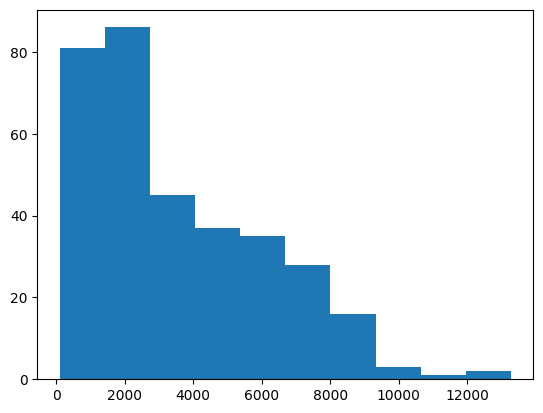

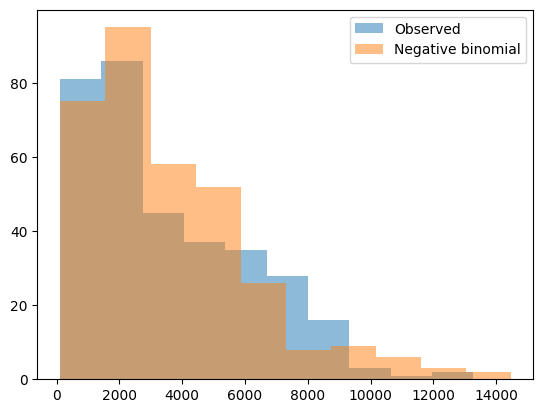

p_hat: 0.001005948939264576
curvature: 2849908805.3273587
standard error: 1.87320159287788e-05


In [ ]:
# 1. Import

import csv
import matplotlib.pyplot as plt
import statistics
import numpy as np
import math
from scipy.optimize import minimize_scalar
from scipy.stats import nbinom
import numpy as np
# Google Colab file upload
from google.colab import files


# 2. Data

uploaded = files.upload()


filename = "Database_W5_OTU_occurences.tsv"


# 3. File edit

with open(filename, "r", encoding="utf-8") as file:
    reader = csv.DictReader(file, delimiter="\t")

    sample_columns = []

    for column in reader.fieldnames:
        if column.startswith("TARA_"):
            sample_columns.append(column)

    richness = {}

    for sample in sample_columns:
        richness[sample] = 0

    for row in reader:
        for sample in sample_columns:
            count = float(row[sample])

            if count > 0:
                richness[sample] += 1


print(richness)

print("Mean richness:", statistics.mean(richness.values()))
print("Variance in richness:", statistics.variance(richness.values()))

plt.hist(richness.values())
plt.show()


# 4. Negative binomial

values = np.array(list(richness.values()))

mean = np.mean(values)
variance = np.var(values, ddof=1)

n = mean**2 / (variance - mean)
p = n / (n + mean)

random_nb = np.random.negative_binomial(
    n,
    p,
    size=len(values)
)

plt.hist(values, alpha=0.5, label="Observed")
plt.hist(random_nb, alpha=0.5, label="Negative binomial")

plt.legend()
plt.show()


# 5. Uncertainty
def nll(p):
    if p <= 0 or p >= 1:
        return np.inf

    return -np.sum(
        nbinom.logpmf(values, n, p)
    )


result = minimize_scalar(
    nll,
    bounds=(0.001, 0.999),
    method="bounded"
)

p_hat = result.x

h = 0.001

curvature = (
    nll(p_hat + h)
    - 2 * nll(p_hat)
    + nll(p_hat - h)
) / h**2

se_p = 1 / (curvature**0.5)

print("p_hat:", p_hat)
print("curvature:", curvature)
print("standard error:", se_p)
